# Feature Engineering & Baseline Models

**Level:** Beginner-friendly  
**Goal:** Predict whether an order will be delivered late — binary classification from scratch.

We cover: merging relational tables, creating the target variable, feature engineering, encoding categoricals, and training two baseline models (Logistic Regression + Decision Tree).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
PALETTE = ['#2196F3', '#FF5722']
IMG  = '../images/'
DATA = '../../olist-statistics-science/data/'
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Merge Data

The Olist dataset is split across 9 CSV files. We join them to build one flat feature table.

**Why?** The Olist dataset is a star schema split across 7 CSV files. No single file contains enough information to predict late delivery — we need product weight from one table, seller location from another, payment type from a third. The join strategy and aggregation choices here directly determine what information the model has access to.

In [2]:
orders    = pd.read_csv(DATA + 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
items     = pd.read_csv(DATA + 'olist_order_items_dataset.csv')
products  = pd.read_csv(DATA + 'olist_products_dataset.csv')
customers = pd.read_csv(DATA + 'olist_customers_dataset.csv')
sellers   = pd.read_csv(DATA + 'olist_sellers_dataset.csv')
payments  = pd.read_csv(DATA + 'olist_order_payments_dataset.csv')
cat_trans = pd.read_csv(DATA + 'product_category_name_translation.csv')

print(f'Total orders: {len(orders):,}')
print(f'Delivered:    {(orders.order_status == "delivered").sum():,}')

Total orders: 99,441
Delivered:    96,478


## 2. Create the Target Variable

We keep only delivered orders where both actual and estimated delivery dates are available.

**Why?** Supervised learning needs a label. We define 'late' as delivered after the estimated date — a business-meaningful definition tied to customer expectations, not an arbitrary statistical threshold. Defining the target carefully is the most important decision in any ML project; a wrong label means every metric that follows is measuring the wrong thing.

In [3]:
df = orders[orders['order_status'] == 'delivered'].copy()
df = df.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])

# Target: 1 = delivered after estimated date, 0 = on time
df['is_late'] = (
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
).astype(int)

# Time-based features from order timestamps
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['purchase_dow']   = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_hour']  = df['order_purchase_timestamp'].dt.hour

print(f'Working dataset: {len(df):,} orders')
print(f'Late deliveries: {df["is_late"].sum():,}  ({df["is_late"].mean()*100:.1f}%)')

Working dataset: 96,470 orders
Late deliveries: 7,826  (8.1%)


## 3. Feature Engineering

We pull in product weight/volume, item count, freight cost, payment type, and a same-state flag (proxy for distance).

**Why?** Raw timestamps and ID columns aren't useful to a model. We extract signals that capture the underlying logistics reality: how long was the delivery window promised, how heavy is the product, are seller and customer in the same state? The model can only learn from what we give it — feature engineering is where domain knowledge becomes predictive power.

In [4]:
# Order-level item aggregation
items_agg = items.groupby('order_id').agg(
    item_count    = ('order_item_id', 'count'),
    total_price   = ('price', 'sum'),
    freight_value = ('freight_value', 'sum'),
    seller_id     = ('seller_id', 'first')
).reset_index()

# Product weight & volume
items_prod = items.merge(
    products[['product_id','product_weight_g','product_length_cm',
              'product_height_cm','product_width_cm']], on='product_id', how='left'
)
prod_agg = items_prod.groupby('order_id').agg(
    product_weight_g = ('product_weight_g', 'mean'),
    product_volume   = ('product_length_cm',
        lambda x: (x * items_prod.loc[x.index,'product_height_cm']
                     * items_prod.loc[x.index,'product_width_cm']).mean())
).reset_index()

# Payment info
pay_agg = payments.groupby('order_id').agg(
    payment_type         = ('payment_type', 'first'),
    payment_installments = ('payment_installments', 'max')
).reset_index()

# Seller state
items_agg = items_agg.merge(sellers[['seller_id','seller_state']], on='seller_id', how='left')

# Merge everything
df = (df
    .merge(items_agg, on='order_id', how='left')
    .merge(prod_agg,  on='order_id', how='left')
    .merge(pay_agg,   on='order_id', how='left')
    .merge(customers[['customer_id','customer_state']], on='customer_id', how='left')
)

# Same-state flag: seller and customer in same state → shorter route
df['same_state'] = (df['seller_state'] == df['customer_state']).astype(int)

print(f'Feature table shape: {df.shape}')

Feature table shape: (96470, 24)


## 4. Exploratory Analysis

**Why?** Before training anything, we visualize class distribution and feature relationships with the target. This reveals critical facts: ~8% late rate (class imbalance), November spike (seasonal signal), same-state effect (geographic signal). Without EDA, we'd train blind and have no way to sanity-check what the model learns.

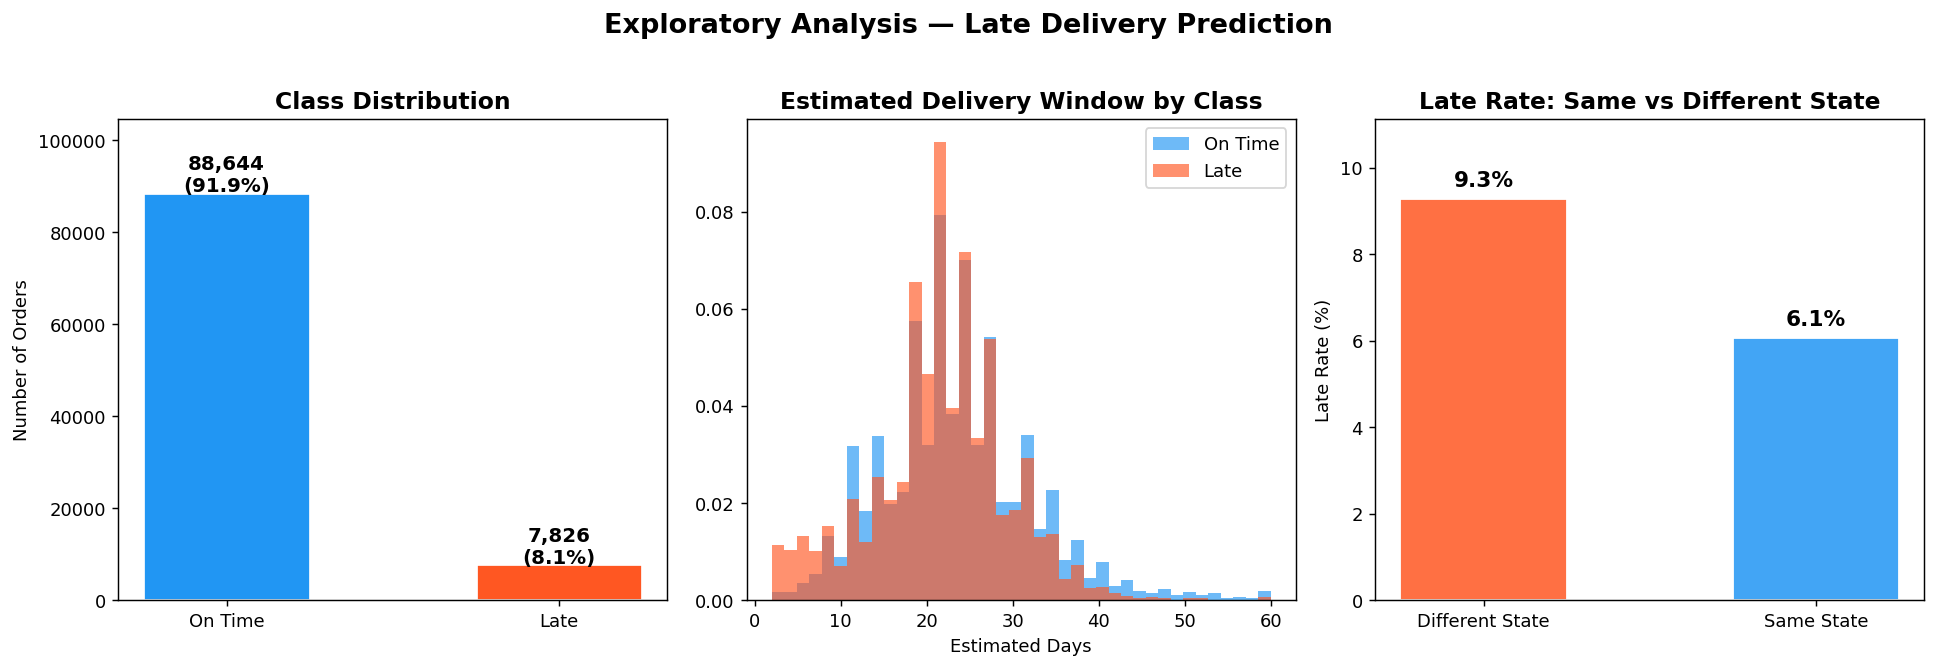

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Class distribution
counts = df['is_late'].value_counts().sort_index()
axes[0].bar(['On Time', 'Late'], counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].set_ylim(0, counts.max() * 1.18)

# Estimated days distribution by class
for lbl, col, clr in zip(['On Time','Late'], [0,1], PALETTE):
    axes[1].hist(df[df['is_late']==col]['estimated_days'].clip(0,60),
                 bins=40, alpha=0.65, color=clr, label=lbl, density=True)
axes[1].set_title('Estimated Delivery Window by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Estimated Days')
axes[1].legend()

# Late rate by same_state
ss = df.groupby('same_state')['is_late'].mean() * 100
bars = axes[2].bar(['Different State','Same State'], ss.values,
                   color=['#FF7043','#42A5F5'], edgecolor='white', width=0.5)
for bar, val in zip(bars, ss.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Late Rate: Same vs Different State', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Late Rate (%)')
axes[2].set_ylim(0, ss.max() * 1.2)

plt.suptitle('Exploratory Analysis — Late Delivery Prediction', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG + '01_eda.png', bbox_inches='tight')
plt.show()

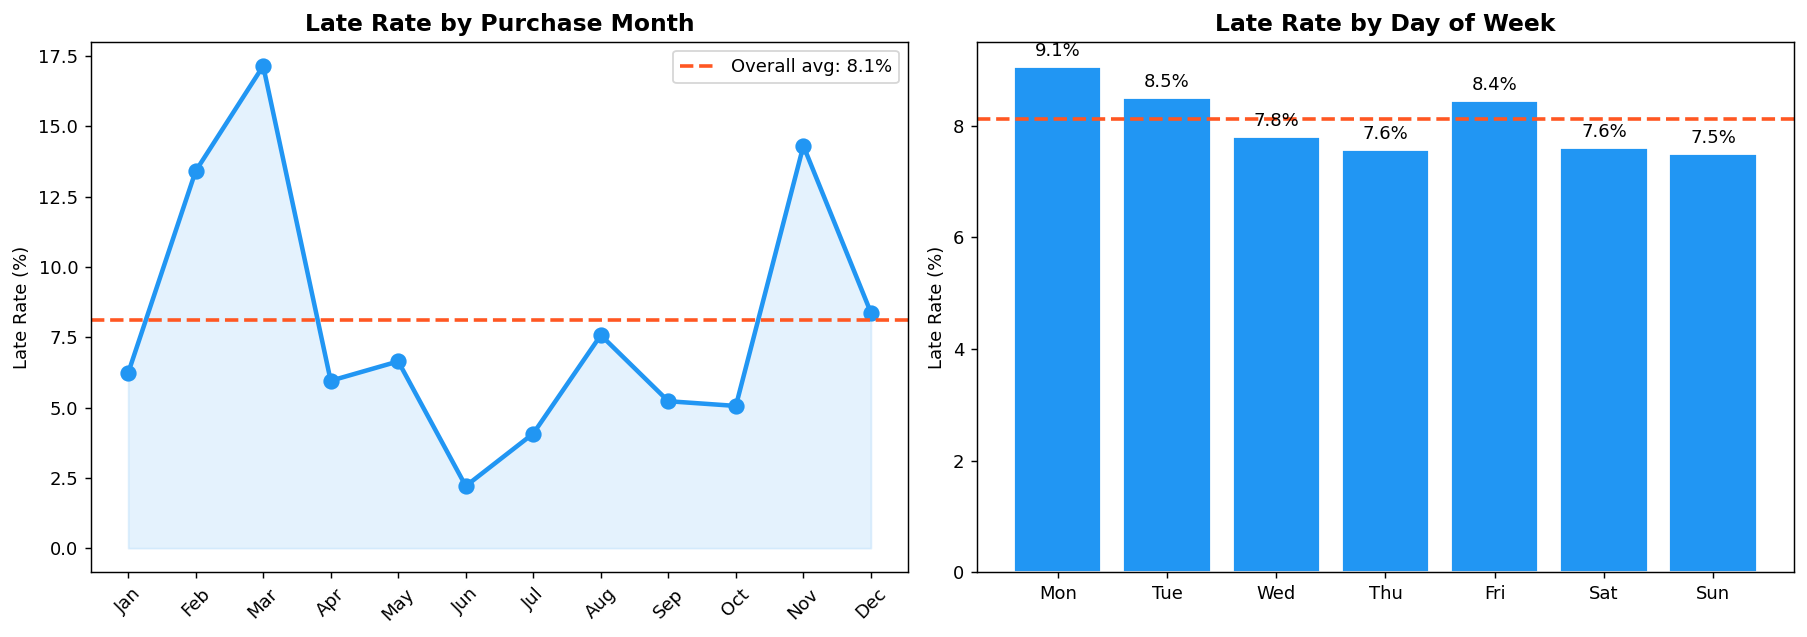

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_late = df.groupby('purchase_month')['is_late'].mean() * 100
axes[0].plot(month_late.index, month_late.values, marker='o', color='#2196F3', linewidth=2.5, markersize=8)
axes[0].fill_between(month_late.index, month_late.values, alpha=0.12, color='#2196F3')
axes[0].axhline(df['is_late'].mean()*100, ls='--', color='#FF5722', linewidth=2,
                label=f'Overall avg: {df["is_late"].mean()*100:.1f}%')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].set_title('Late Rate by Purchase Month', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Late Rate (%)')
axes[0].legend()

dow_late = df.groupby('purchase_dow')['is_late'].mean() * 100
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
bars = axes[1].bar(days, dow_late.values, color='#2196F3', edgecolor='white')
for bar, val in zip(bars, dow_late.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=10)
axes[1].axhline(df['is_late'].mean()*100, ls='--', color='#FF5722', linewidth=2)
axes[1].set_title('Late Rate by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Late Rate (%)')

plt.tight_layout()
plt.savefig(IMG + '01_temporal_patterns.png', bbox_inches='tight')
plt.show()

> **Key insight:** ~8% of orders arrive late. Cross-state shipments are delayed at nearly double the rate of same-state orders. November spikes above the average — Black Friday strains the logistics network and it shows in the data.

## 5. Prepare Features for Modeling

**Why?** Models need numbers in expected ranges. LabelEncoder converts categories to integers, median imputation handles missing values without distorting distributions, and StandardScaler puts all features on the same scale for Logistic Regression (which is sensitive to feature magnitude — unscaled features can make the optimizer converge slowly or not at all).

In [7]:
FEATURES = [
    'estimated_days', 'item_count', 'total_price', 'freight_value',
    'product_weight_g', 'product_volume', 'payment_installments', 'same_state',
    'purchase_dow', 'purchase_month', 'purchase_hour',
    'payment_type', 'customer_state'
]
TARGET = 'is_late'

model_df = df[FEATURES + [TARGET]].copy()

# Fill numeric NaN with median
num_cols = ['estimated_days','item_count','total_price','freight_value',
            'product_weight_g','product_volume','payment_installments']
for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Encode categoricals
le_pay   = LabelEncoder()
le_state = LabelEncoder()
model_df['payment_type']   = le_pay.fit_transform(model_df['payment_type'].fillna('unknown'))
model_df['customer_state'] = le_state.fit_transform(model_df['customer_state'].fillna('unknown'))

print(f'Feature matrix: {model_df.shape}')
print(f'Missing values: {model_df.isnull().sum().sum()}')

Feature matrix: (96470, 14)
Missing values: 0


In [8]:
X = model_df.drop(TARGET, axis=1)
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Late in train: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')

Train: 77,176  |  Test: 19,294
Late in train: 6,261 (8.1%)


## 6. Logistic Regression

**Why?** We start with the simplest model that could plausibly work. Logistic Regression is fast, interpretable (coefficients are readable), and sets a performance floor. It also forces us to confront class imbalance upfront — `class_weight='balanced'` tells the model to penalise missing a late delivery more than a false alarm.

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['On Time','Late']))

=== Logistic Regression ===
              precision    recall  f1-score   support

     On Time       0.95      0.58      0.72     17729
        Late       0.12      0.63      0.20      1565

    accuracy                           0.59     19294
   macro avg       0.53      0.61      0.46     19294
weighted avg       0.88      0.59      0.68     19294



## 7. Decision Tree

**Why?** Decision Trees capture non-linear relationships and feature interactions that Logistic Regression misses. They're also fully explainable — you can print the actual decision rules. The tree structure visualisation shows us which features the model splits on first, which is a useful sanity check on our feature engineering.

In [10]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['On Time','Late']))

=== Decision Tree ===
              precision    recall  f1-score   support

     On Time       0.96      0.76      0.85     17729
        Late       0.18      0.60      0.28      1565

    accuracy                           0.74     19294
   macro avg       0.57      0.68      0.56     19294
weighted avg       0.89      0.74      0.80     19294



## 8. Visualizations

**Why?** Classification metrics tables are compact but incomplete. Confusion matrices show exactly *where* each model fails — how many late orders we miss (false negatives) vs. how many on-time orders we wrongly flag (false positives). These have asymmetric business costs, and a table of F1 scores hides that asymmetry.

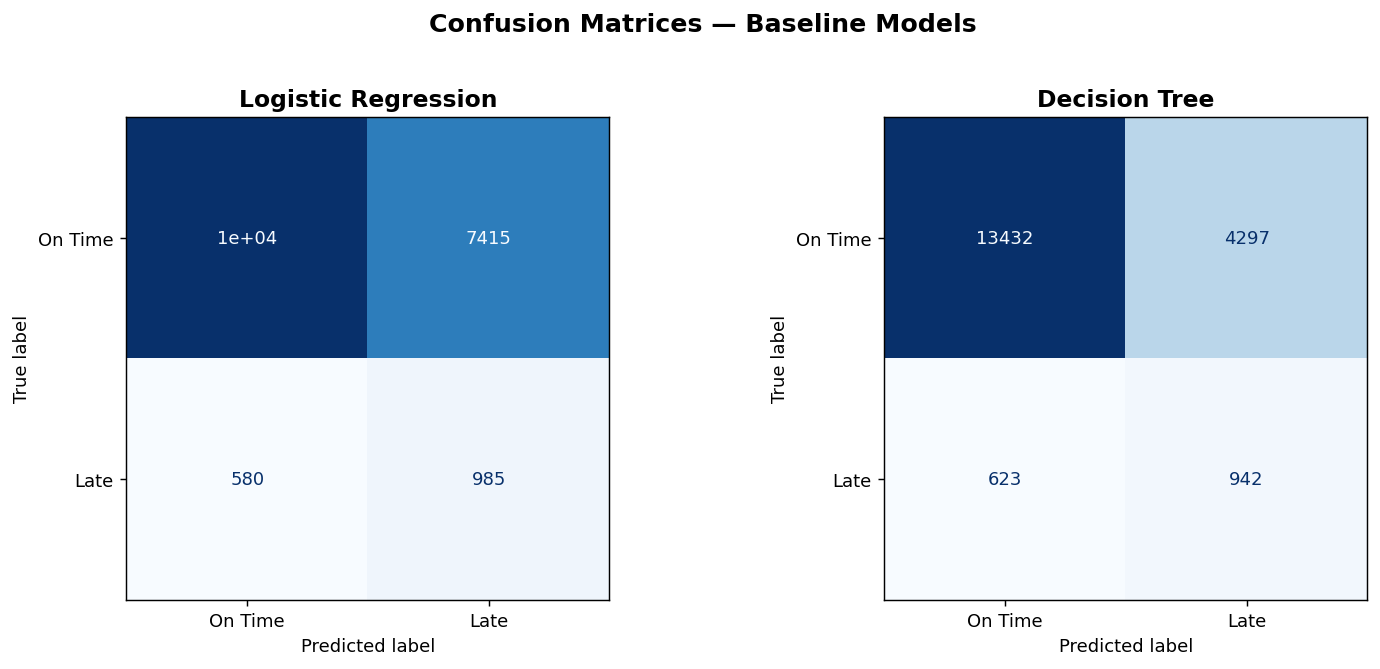

In [11]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['On Time','Late']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Baseline Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG + '01_confusion_matrices.png', bbox_inches='tight')
plt.show()

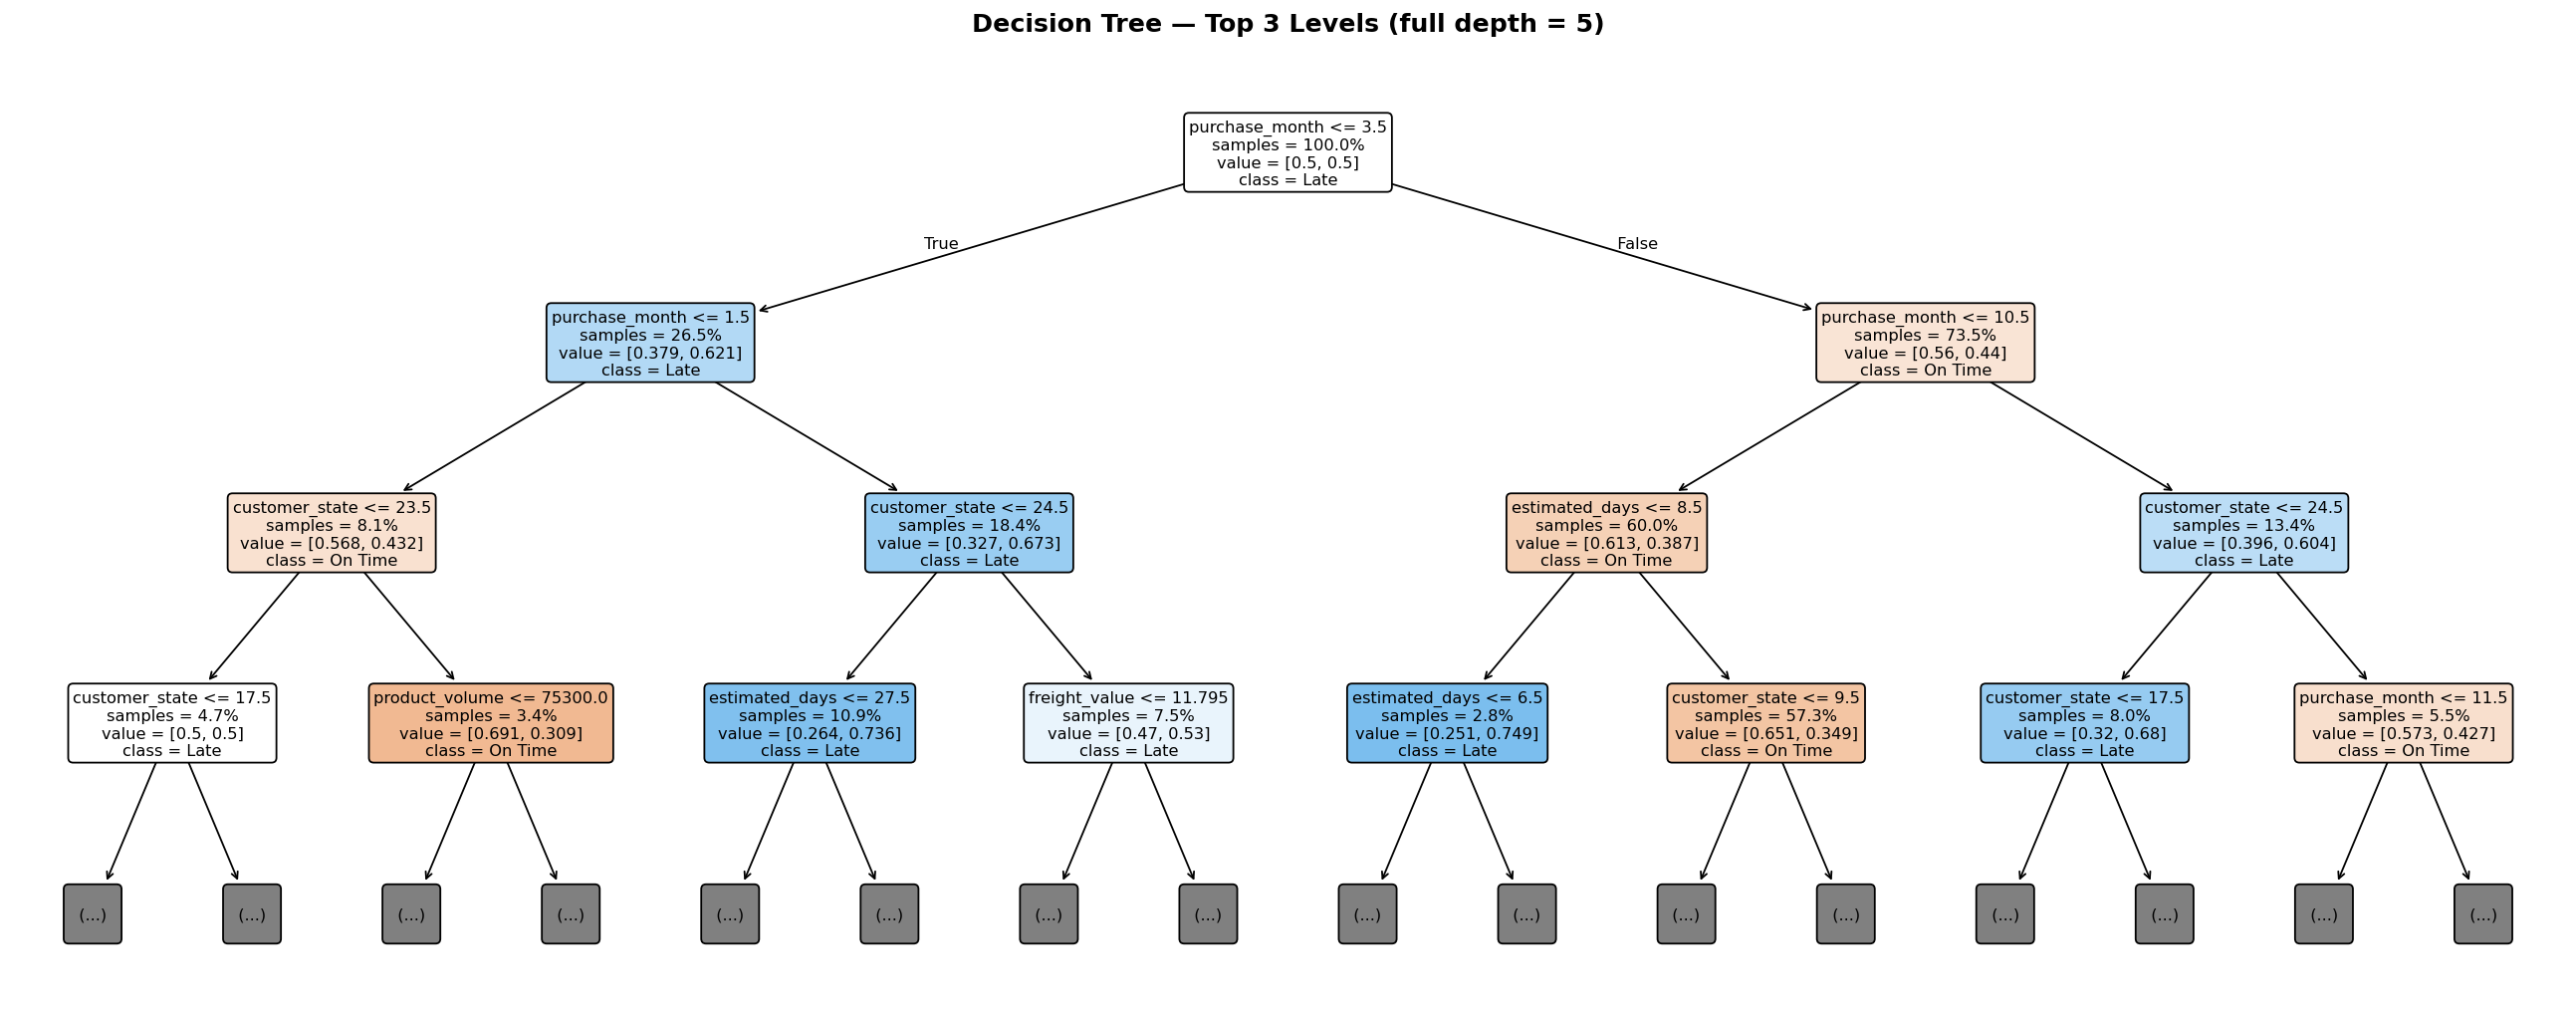

In [12]:
# Decision tree visualization
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt, feature_names=FEATURES, class_names=['On Time','Late'],
    filled=True, rounded=True, max_depth=3, ax=ax,
    fontsize=9, impurity=False, proportion=True
)
ax.set_title('Decision Tree — Top 3 Levels (full depth = 5)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(IMG + '01_decision_tree.png', bbox_inches='tight')
plt.show()

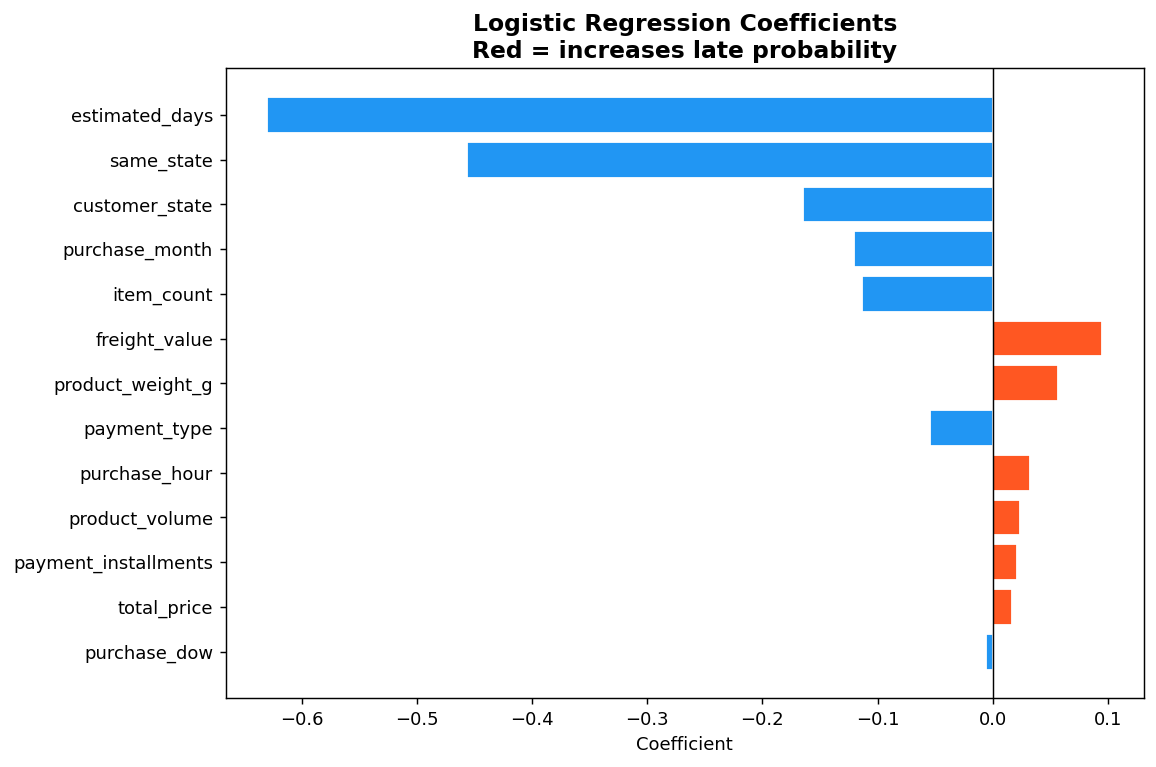

In [13]:
# LR coefficients
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values().index)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#FF5722' if c > 0 else '#2196F3' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\nRed = increases late probability', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig(IMG + '01_lr_coefficients.png', bbox_inches='tight')
plt.show()

In [14]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy':  [accuracy_score(y_test, p) for p in [y_pred_lr, y_pred_dt]],
    'Precision': [precision_score(y_test, p) for p in [y_pred_lr, y_pred_dt]],
    'Recall':    [recall_score(y_test, p)    for p in [y_pred_lr, y_pred_dt]],
    'F1':        [f1_score(y_test, p)        for p in [y_pred_lr, y_pred_dt]],
}).set_index('Model').round(4)

print(results)

# Save for notebook 2
import pickle, os
os.makedirs('../data', exist_ok=True)
with open('../data/nb1_artifacts.pkl', 'wb') as f:
    pickle.dump({'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train, 'y_test': y_test,
                 'FEATURES': FEATURES}, f)
print('\nArtifacts saved for notebook 2.')

                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.5856     0.1173  0.6294  0.1977
Decision Tree          0.7450     0.1798  0.6019  0.2769

Artifacts saved for notebook 2.


> **Key insight:** With ~8% late-delivery rate, accuracy alone is deceptive — a model that always predicts 'on time' would score 92%. What matters is **recall on the Late class** (how many actual delays do we catch?). Logistic Regression gets more recall but at the cost of too many false alarms. Decision Tree is more conservative. Neither is production-ready — that's what notebooks 2 and 3 are for.